## 1. Librerías y Carga de Datos.

* Se define si se utilizará Plotly para las gráficas y se importan las librerías necesarias para análisis de datos, visualización y modelado de series temporales.

Recomendaciones:  Para un mejor entendimiento de las gráficas o su uso local cambiar el valor de `USE_PLOTRLY` a `True`

In [1]:
# Control de visualización: desactivar Plotly para generar gráficas con Matplotlib/Seaborn en este notebook.
USE_PLOTLY = True
# Nota: Plotly puede habilitarse para uso local cambiando a True si se desea interactividad.

### 1.1. Librerías

In [2]:
import sys
sys.path.append('../../')

In [3]:
import src.utils.helpers as func
import src.evaluation.metrics as meval
from src.utils.ts_diagnostics import StationarityAnalyzer, analyze_decomposition
from src.visualization import tsa_plots as tsp
from src.evaluation.interpretability import get_xbg_feature_importance
#from src.evaluation.plots import plot_last_year, plot_residuals_distribution, plot_forecast

In [4]:
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from tabulate import tabulate
import warnings
warnings.filterwarnings("ignore")

### 1.2 Argumentos Comunes para Graficar

In [7]:
# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    'hover_mode': 'x unified',
}

## Modelos de machine learning

### Carga y preparación de datos

In [8]:
path = '../../data/processed/df_acumulado.parquet'
df_completo = func.load_data(path, show_info=False)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Datos cargados exitosamente.


In [9]:
def prepare_data(data):
    df = data[['fecha', 'valor_acumulado_corregido']].copy()
    df['valor']= df['valor_acumulado_corregido'].diff()
    df.loc[0, 'valor'] = df.iloc[0]['valor_acumulado_corregido']
    df.drop(columns=['valor_acumulado_corregido'], inplace=True)
    return df

In [10]:
data = prepare_data(df_completo)

In [11]:
df = data[['fecha', 'valor']].copy()
df.rename(columns={'fecha': 'ds', 'valor': 'y'}, inplace=True)
df.set_index('ds',inplace=True)
df.index = pd.to_datetime(df.index)
#df = df.resample('W').mean().fillna(method='ffill')
df.head()

,y
ds,
2014-01-06,131.0
2014-01-13,658.0
2014-01-20,933.0
2014-01-27,1023.0
2014-02-03,1151.0


### Modelo simple

Preparación de Datos y Feature Engineering

In [12]:
def create_features(data, lag_steps=52):
    """Crea features de tiempo y lags para el modelo XGBoost."""
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['week_of_year'] = data.index.isocalendar().week.astype(int) # Esencial por la estacionalidad semanal

    # Lags (valores pasados)
    for i in range(1, lag_steps + 1):
        # Creamos los lags que el modelo aprenderá a usar
        data[f'lag_{i}'] = data['y'].shift(i)

    # Creamos un indicador para el paso de predicción (útil en enfoques recursivos)
    data['prediction_step'] = 0

    return data.dropna()

In [13]:
# Aplicar el Feature Engineering
df_features = create_features(df.copy())

División de Datos y Entrenamiento del Modelo

Dividiremos los datos en entrenamiento y prueba, reservando las últimas semanas para la validación.

In [14]:
# Definición del horizonte de predicción (por ejemplo, las últimas 52 semanas/1 año)
FORECAST_HORIZON = 52

# Definición de X (features) e y (target)
target = 'y'
features = [col for col in df_features.columns if col not in [target, 'ds']]

In [15]:
# Separar conjuntos de Entrenamiento y Prueba
# Entrenamiento: todos los datos menos el horizonte de predicción
train_cutoff = df_features.index[-FORECAST_HORIZON]
X_train = df_features.loc[df_features.index < train_cutoff, features]
y_train = df_features.loc[df_features.index < train_cutoff, target]

# Prueba: solo el horizonte de predicción
X_test_initial = df_features.loc[df_features.index >= train_cutoff, features]
y_test = df_features.loc[df_features.index >= train_cutoff, target]

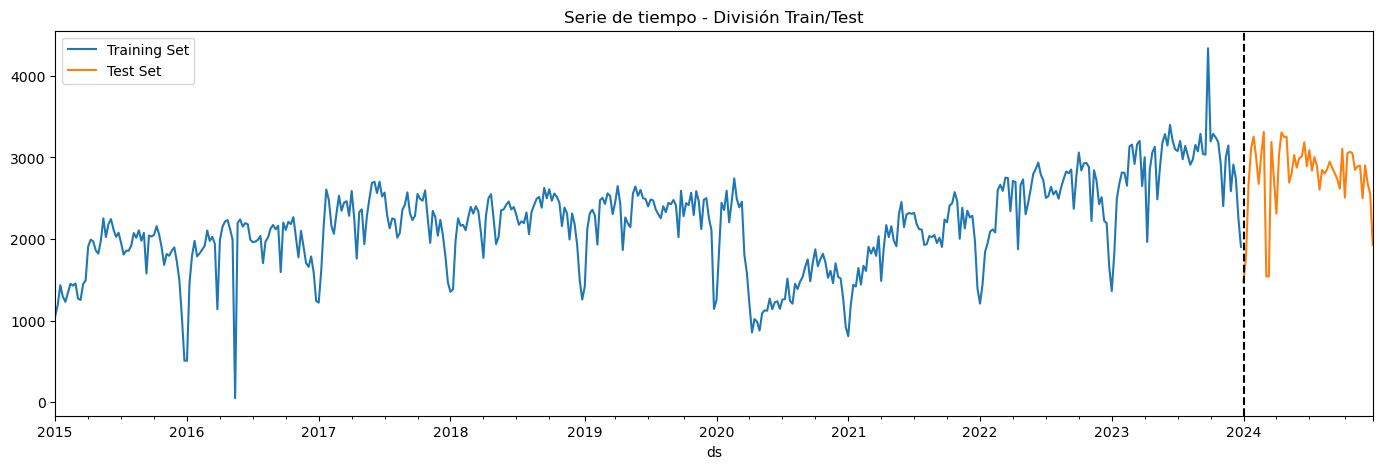

In [16]:
# Visaluzación de división de sets
fig,ax=plt.subplots(figsize=(17,5))
y_train.plot(ax=ax, label='Train Set', title='Serie de tiempo - División Train/Test')
y_test.plot(ax=ax, label='Test Set')
ax.axvline(y_test.index[0], color='black', linestyle='--', label='Inicio Test Set')
ax.legend(['Training Set', 'Test Set'])
plt.show()

In [17]:
# --- Entrenamiento del Modelo ---
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    early_stopping_rounds=10,
    tree_method='hist' # Más rápido para grandes datasets
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

Función de Predicción Recursiva (El Núcleo del Modelo)

Aquí implementamos la lógica recursiva: la predicción del paso $t$ se usa para calcular el lag que alimentará la predicción del paso $t+1$.

In [18]:
def recursive_forecast(model, initial_X_test, horizon, lag_steps=52):
    """
    Realiza predicciones recursivas usando las predicciones anteriores como features de lag.
    """
    # Hacer una copia para modificar los lags
    current_X = initial_X_test.copy()
    predictions = []

    # Iterar paso a paso por el horizonte de predicción
    for step in range(horizon):
        # 1. Preparar la entrada X para la predicción actual (fila 'step')
        X_now = current_X.iloc[[step]].copy()
        X_now['prediction_step'] = step + 1

        # 2. Hacer la predicción
        pred_value = model.predict(X_now)[0]
        predictions.append(pred_value)

        # 3. Actualizar los Lags para el siguiente paso (si no es el último)
        if step < horizon - 1:
            # Shift all lags one position to the right (lag_1 becomes lag_2, etc.)
            for i in range(lag_steps, 1, -1):
                current_X.iloc[step + 1, current_X.columns.get_loc(f'lag_{i}')] = \
                    current_X.iloc[step + 1, current_X.columns.get_loc(f'lag_{i-1}')]

            # El lag_1 para el siguiente paso (step + 1) es la predicción actual (pred_value)
            current_X.iloc[step + 1, current_X.columns.get_loc('lag_1')] = pred_value

    return np.array(predictions)

In [19]:
# Ejecutar el Forecasting Recursivo
forecast_predictions = recursive_forecast(model, X_test_initial, FORECAST_HORIZON)

# Crear un DataFrame para los resultados
forecast_df = pd.DataFrame({
    'Actual': y_test.values,
    'XGBoost_Recursive': forecast_predictions
}, index=y_test.index)

Evaluación de Resultados

Finalmente, evaluamos el rendimiento del modelo en el conjunto de prueba.

In [20]:
# --- Evaluación del Modelo ---
mse = mean_squared_error(forecast_df['Actual'], forecast_df['XGBoost_Recursive'])
rmse = np.sqrt(mse)

print(f"XGBoost Recursivo completado para un horizonte de {FORECAST_HORIZON} semanas.")
print(f"Error Cuadrático Medio (RMSE) en el set de prueba: {rmse:.2f}")

XGBoost Recursivo completado para un horizonte de 52 semanas.
Error Cuadrático Medio (RMSE) en el set de prueba: 466.60


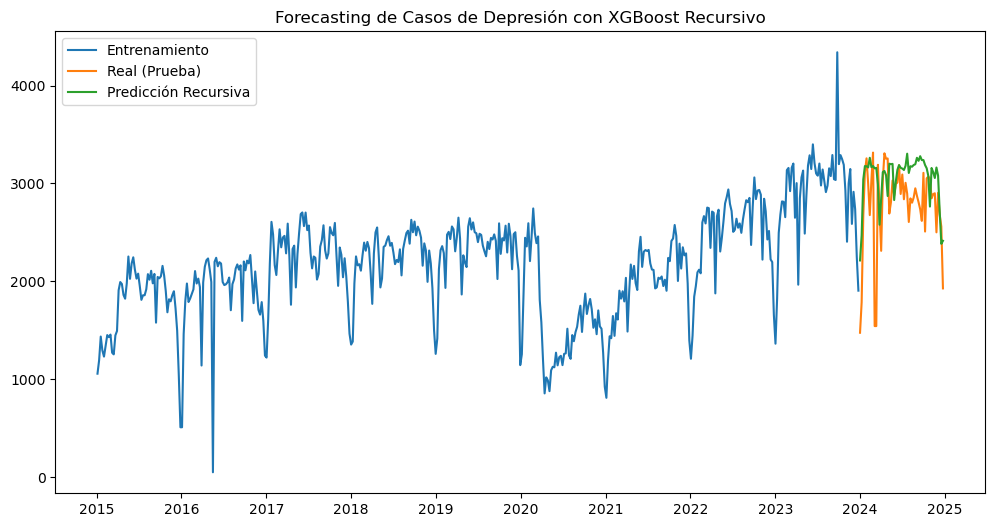

In [21]:
# --- Visualización (Opcional) ---
plt.figure(figsize=(12, 6))
plt.plot(y_train, label='Entrenamiento')
plt.plot(forecast_df['Actual'], label='Real (Prueba)')
plt.plot(forecast_df['XGBoost_Recursive'], label='Predicción Recursiva')
plt.title('Forecasting de Casos de Depresión con XGBoost Recursivo')
plt.legend()
plt.show()

### Modelo con variables de tendencia y estacionalidad

Basado en la descomposición de tu serie (fuerte tendencia a largo plazo y estacionalidad semanal/anual muy marcada), vamos a añadir:

Tendencia: Usando un simple contador de tiempo.

Estacionalidad Anual/Semanal: Usando Términos de Fourier (senos y cosenos).

Definición de la Función Extendida

In [22]:
def create_advanced_features(data, lag_steps=52, n_fourier=6):
    """
    Crea features de tiempo, lags, tendencia y estacionalidad de Fourier.
    """
    df_features = data.copy()

    # --- A. Features de Tiempo Básicas ---
    df_features['year'] = df_features.index.year
    df_features['week_of_year'] = df_features.index.isocalendar().week.astype(int)
    # Puede ser útil el día de la semana para la recurrencia semanal (si la frecuencia es diaria)
    # df_features['day_of_week'] = df_features.index.dayofweek

    # --- B. Tendencia (Contador de Tiempo Escalandado) ---
    # Un simple contador numérico que aumenta con el tiempo
    df_features['time_index'] = np.arange(len(df_features))
    
    # Es muy recomendable escalar el tiempo si se usa un modelo basado en árboles
    scaler_time = StandardScaler()
    df_features['Trend'] = scaler_time.fit_transform(df_features[['time_index']])
    df_features.drop(columns=['time_index'], inplace=True) # Eliminamos el original sin escalar

    # --- C. Estacionalidad con Términos de Fourier ---
    # Usamos la cantidad de semanas en el año (52.17)
    P = 52.17
    t = np.arange(len(df_features))

    for k in range(1, n_fourier + 1):
        df_features[f'sin_{k}'] = np.sin(2 * np.pi * k * t / P)
        df_features[f'cos_{k}'] = np.cos(2 * np.pi * k * t / P)

    # --- D. Lags (Valores Pasados) ---
    for i in range(1, lag_steps + 1):
        df_features[f'lag_{i}'] = df_features['y'].shift(i)
        
    # Indicador para el paso de predicción (para el forecasting recursivo)
    df_features['prediction_step'] = 0

    return df_features.dropna()

In [23]:
# Aplicar el Feature Engineering Extendido
df_features_ext = create_advanced_features(df.copy(), lag_steps=52, n_fourier=6)

In [24]:
# Definición del horizonte de predicción (por ejemplo, las últimas 52 semanas/1 año)
FORECAST_HORIZON = 52

# Definición de X (features) e y (target) actualizada
target = 'y'
features = [col for col in df_features_ext.columns if col not in [target, 'ds']]

In [25]:
# Separar conjuntos de Entrenamiento y Prueba
# Entrenamiento: todos los datos menos el horizonte de predicción
train_cutoff = df_features_ext.index[-FORECAST_HORIZON]
X_train = df_features_ext.loc[df_features_ext.index < train_cutoff, features]
y_train = df_features_ext.loc[df_features_ext.index < train_cutoff, target]

# Prueba: solo el horizonte de predicción
X_test_initial = df_features_ext.loc[df_features_ext.index >= train_cutoff, features]
y_test = df_features_ext.loc[df_features_ext.index >= train_cutoff, target]

In [26]:
# --- Entrenamiento del Modelo ---
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    early_stopping_rounds=10,
    tree_method='hist' # Más rápido para grandes datasets
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [27]:
# Ejecutar el Forecasting Recursivo con el modelo ya entrenado
forecast_predictions = recursive_forecast(model, X_test_initial, FORECAST_HORIZON)

# Crear un DataFrame para los resultados
forecast_df_2 = pd.DataFrame({
    'Actual': y_test.values,
    'XGBoost_Recursive': forecast_predictions
}, index=y_test.index)

In [28]:
# --- Evaluación del Modelo ---
mse = mean_squared_error(forecast_df_2['Actual'], forecast_df_2['XGBoost_Recursive'])
rmse = np.sqrt(mse)

print(f"XGBoost Recursivo completado para un horizonte de {FORECAST_HORIZON} semanas.")
print(f"Error Cuadrático Medio (RMSE) en el set de prueba: {rmse:.2f}")

XGBoost Recursivo completado para un horizonte de 52 semanas.
Error Cuadrático Medio (RMSE) en el set de prueba: 464.19


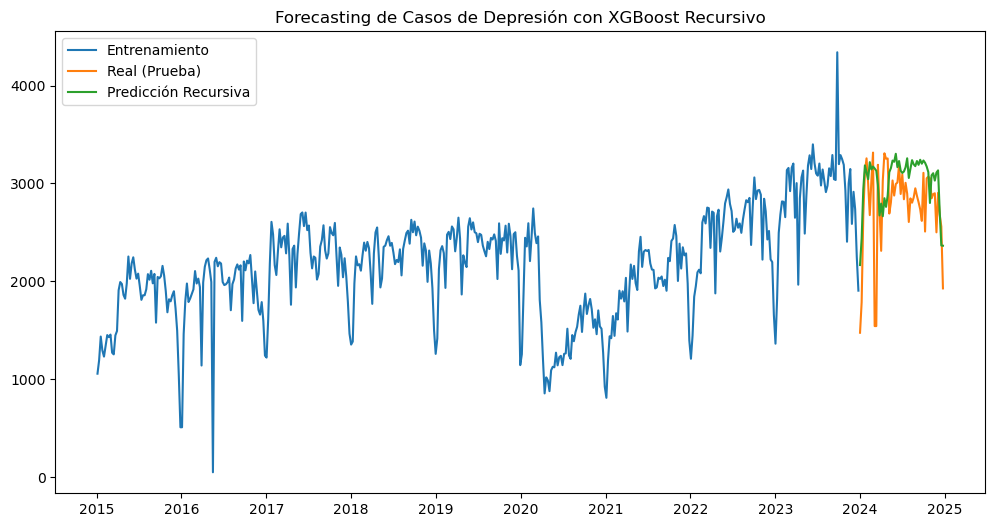

In [29]:
# --- Visualización (Opcional) ---
plt.figure(figsize=(12, 6))
plt.plot(y_train, label='Entrenamiento')
plt.plot(forecast_df_2['Actual'], label='Real (Prueba)')
plt.plot(forecast_df_2['XGBoost_Recursive'], label='Predicción Recursiva')
plt.title('Forecasting de Casos de Depresión con XGBoost Recursivo')
plt.legend()
plt.show()

### Modelo con optimización de Hiperparámetros con TimeSeriesSplit

Configuración de la Validación Cruzada

La clase TimeSeriesSplit crea divisiones donde el conjunto de entrenamiento siempre precede al conjunto de validación, simulando el proceso de forecasting en la vida real.

In [30]:
from sklearn.model_selection import train_test_split
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.1, 
    shuffle=False, # ¡Importante! No mezclar datos de series de tiempo.
    random_state=42
)

In [31]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, make_scorer

# 1. Definir los datos de entrenamiento (Usamos el set completo con features avanzados)
# Excluimos las filas que tienen NaNs por los lags
df_train = df_features_ext.dropna()
X = df_train.drop(columns=['y', 'prediction_step']) # Excluimos el target y el indicador recursivo
y = df_train['y']

# 2. Definir el esquema de Validación Cruzada
# n_splits=5 significa que tendremos 5 rondas de entrenamiento/validación.
# test_size define cuántos pasos (semanas) se usarán para la validación en cada fold.
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=52 # Validar sobre 52 semanas (1 año) en cada fold
)

# 3. Definir la Métrica de Puntuación (Scorer)
# Queremos minimizar el Error Cuadrático Medio (RMSE) o el MSE.
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)

Definición del Espacio de Búsqueda

Seleccionamos los hiperparámetros más influyentes de XGBoost para optimizar

In [32]:
# Definición del espacio de búsqueda para los hiperparámetros
param_grid = {
    # Número de árboles: un rango razonable
    'n_estimators': [500, 1000, 1500, 2000],
    
    # Tasa de aprendizaje: afecta el tiempo y la precisión
    'learning_rate': [0.01, 0.05, 0.1],
    
    # Profundidad máxima del árbol: controla la complejidad y el sobreajuste
    'max_depth': [3, 5, 7, 10],
    
    # Mínimo peso de la hoja: evita el sobreajuste
    'min_child_weight': [1, 5, 10],
    
    # Submuestreo de columnas por árbol (ayuda a prevenir el sobreajuste)
    'colsample_bytree': [0.7, 0.9, 1.0],
}

Ejecución de la Búsqueda

Usaremos RandomizedSearchCV ya que es mucho más eficiente que GridSearchCV para espacios de búsqueda grandes, probando una muestra aleatoria de combinaciones

In [33]:
# 4. Inicializar el modelo base
xgb = XGBRegressor(random_state=42, tree_method='hist')

# 5. Configurar la Búsqueda Aleatoria
# n_iter: número de combinaciones de parámetros a probar (ajusta según el tiempo disponible)
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50, # Prueba 50 combinaciones al azar (ajustar según el tiempo)
    scoring=rmse_scorer,
    cv=tscv,
    verbose=2,
    n_jobs=-1, # Usa todos los núcleos del procesador
    random_state=42
)

# 6. Ejecutar la Búsqueda
print("Iniciando la búsqueda de hiperparámetros...")
# Nota: Este proceso puede tardar varios minutos u horas dependiendo del tamaño de los datos y n_iter.
random_search.fit(X, y)

# 7. Obtener los mejores resultados
best_rmse = -random_search.best_score_ # Convertir a RMSE positivo
best_params = random_search.best_params_

print("\n--- Resultados de la Búsqueda ---")
print(f"Mejor RMSE promedio en validación: {best_rmse:.2f}")
print(f"Mejores Hiperparámetros: {best_params}")

Iniciando la búsqueda de hiperparámetros...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- Resultados de la Búsqueda ---
Mejor RMSE promedio en validación: 415.56
Mejores Hiperparámetros: {'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.9}


In [34]:
# 1. Quita la clave 'n_estimators' de tu diccionario
if 'n_estimators' in best_params:
    del best_params['n_estimators']
    
# Creamos el modelo final con los parámetros óptimos encontrados. 
# Importante: Establecemos un 'n_estimators' alto para que la Parada Temprana lo limite.
final_model = XGBRegressor(
    random_state=42, 
    tree_method='hist',
    n_estimators=3000, # Un número alto para que Early Stopping actúe
    eval_metrics=["rmse"], 
    # Detener si el RMSE de la validación no mejora durante 50 rondas.
    early_stopping_rounds=20, 
    **best_params
)

In [35]:
# Definimos los conjuntos de evaluación para la Parada Temprana
eval_set_final = [
    (X_train_model, y_train_model), # Set de Entrenamiento
    (X_val, y_val)                    # Set de Validación Interna (el 10% que separamos)
]

# Entrenamos el modelo. Aquí es donde agregas la parada temprana.
print("\nIniciando entrenamiento final con Early Stopping...")
model_history = final_model.fit(
    X_train_model, 
    y_train_model, 
    eval_set=eval_set_final,    
    verbose=100
)

optimal_n_estimators = final_model.best_iteration

print(f"✅ Entrenamiento Finalizado por Parada Temprana en {optimal_n_estimators} árboles.")


Iniciando entrenamiento final con Early Stopping...
[0]	validation_0-rmse:468.57328	validation_1-rmse:984.39134
[100]	validation_0-rmse:275.94805	validation_1-rmse:673.41961
[200]	validation_0-rmse:210.01504	validation_1-rmse:560.60825
[300]	validation_0-rmse:176.22060	validation_1-rmse:512.60748
[400]	validation_0-rmse:158.75585	validation_1-rmse:486.36792
[500]	validation_0-rmse:144.51163	validation_1-rmse:477.69949
[600]	validation_0-rmse:135.56012	validation_1-rmse:471.06212
[700]	validation_0-rmse:126.04183	validation_1-rmse:466.44023
[800]	validation_0-rmse:117.74250	validation_1-rmse:461.50838
[900]	validation_0-rmse:110.62056	validation_1-rmse:455.47725
[937]	validation_0-rmse:107.61519	validation_1-rmse:455.26518
✅ Entrenamiento Finalizado por Parada Temprana en 918 árboles.


In [36]:
# --- 4. FORECASTING RECURSIVO Y EVALUACIÓN FINAL ---

# Re-entrenamos con el número óptimo de árboles en todo el X_train completo (si es necesario)
# Ya que XGBoost es aditivo, solo necesitamos ajustar n_estimators al valor óptimo:
final_model.set_params(n_estimators=optimal_n_estimators)

# Ejecutar el Forecasting Recursivo con el modelo ya entrenado
final_predictions = recursive_forecast(final_model, X_test_initial.copy(), FORECAST_HORIZON)

# Crear un DataFrame para los resultados
forecast_df_3 = pd.DataFrame({
    'Actual': y_test.values,
    'XGBoost_Recursive': final_predictions
}, index=y_test.index)

In [37]:
# --- Evaluación Final ---
from sklearn.metrics import mean_squared_error
mse_final = mean_squared_error(y_test, final_predictions)
rmse_final = np.sqrt(mse_final)

print(f"\n--- Rendimiento del Modelo Final ---")
print(f"Error Cuadrático Medio (RMSE) en el set de prueba recursivo final: {rmse_final:.2f}")


--- Rendimiento del Modelo Final ---
Error Cuadrático Medio (RMSE) en el set de prueba recursivo final: 405.09


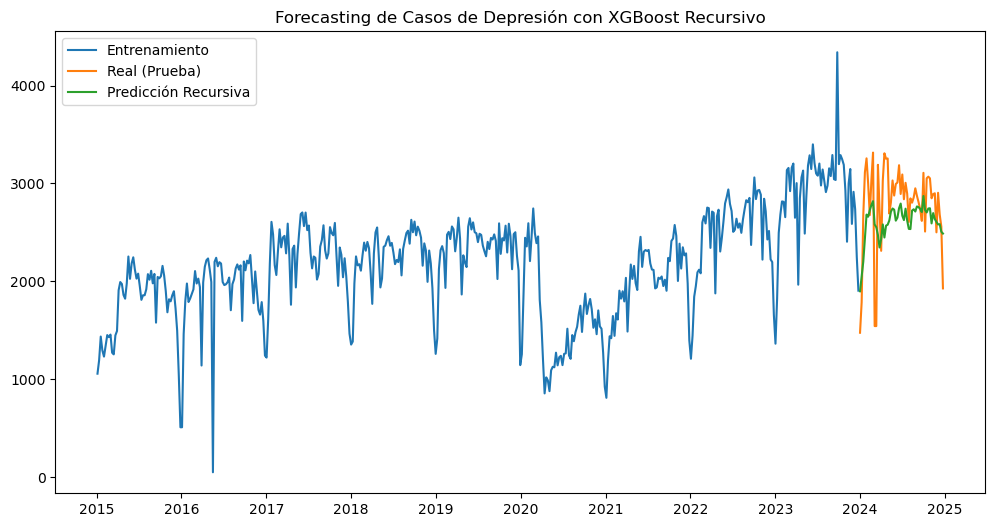

In [38]:
# --- Visualización (Opcional) ---
plt.figure(figsize=(12, 6))
plt.plot(y_train, label='Entrenamiento')
plt.plot(forecast_df_3['Actual'], label='Real (Prueba)')
plt.plot(forecast_df_3['XGBoost_Recursive'], label='Predicción Recursiva')
plt.title('Forecasting de Casos de Depresión con XGBoost Recursivo')
plt.legend()
plt.show()

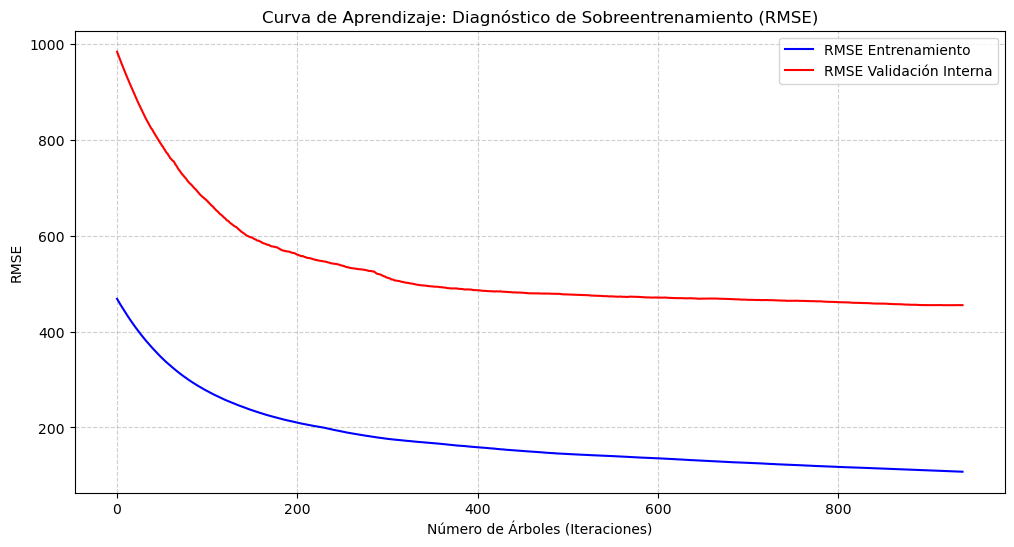

In [39]:
# --- 3. Extraer Resultados ---
results = model_history.evals_result()
epochs = len(results['validation_0']['rmse'])

# --- 4. Crear el Gráfico de la Curva de Aprendizaje ---
plt.figure(figsize=(12, 6))

# Curva de Entrenamiento (validation_0)
plt.plot(
    results['validation_0']['rmse'], 
    label='RMSE Entrenamiento', 
    color='blue'
)

# Curva de Validación (validation_1)
plt.plot(
    results['validation_1']['rmse'], 
    label='RMSE Validación Interna', 
    color='red'
)

plt.title('Curva de Aprendizaje: Diagnóstico de Sobreentrenamiento (RMSE)')
plt.xlabel('Número de Árboles (Iteraciones)')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Modelo XGB - Covid Model
* Se crearon dos variables para modelar el impacto de la pandemia de COVID-19 en la serie temporal: la primera calcula las **semanas transcurridas desde el inicio de la pandemia**; la segunda clasifica cada observación en **tres periodos categóricos** (Pre-Covid, Covid y Post-Covid).

In [40]:
from sklearn.preprocessing import StandardScaler

# --- FECHA ESTIMADA DEL QUIEBRE ESTRUCTURAL ---
# Basado en la visualización, la tendencia cambia significativamente alrededor de abril de 2020.
BREAK_DATE = pd.to_datetime('2020-04-01')

def create_advanced_features_v2(data, lag_steps=52, n_fourier=6):
    """
    Crea features avanzadas, incluyendo tendencia, estacionalidad de Fourier, 
    Lags y el modelado del Quiebre Estructural de 2020.
    """
    df_features = data.copy()

    # --- A. Tendencia Global (Escalada) ---
    df_features['time_index'] = np.arange(len(df_features))
    scaler_time = StandardScaler()
    df_features['Trend_Global'] = scaler_time.fit_transform(df_features[['time_index']])
    df_features.drop(columns=['time_index'], inplace=True) 

    # --- B. Estacionalidad con Términos de Fourier ---
    P = 52.17 # Semanas en un año
    t = np.arange(len(df_features))

    for k in range(1, n_fourier + 1):
        df_features[f'sin_{k}'] = np.sin(2 * np.pi * k * t / P)
        df_features[f'cos_{k}'] = np.cos(2 * np.pi * k * t / P)

    # --- C. Modelado del Quiebre Estructural (NUEVO) ---
    
    # 1. Variable Indicadora (Dummy): Es 1 después de la fecha del quiebre
    df_features['Is_Post_Quiebre'] = (df_features.index >= BREAK_DATE).astype(int)

    # 2. Tendencia Segmentada (Post-Quiebre): Cuenta el tiempo solo a partir del quiebre
    # Esto permite al modelo aprender una PENDIENTE diferente después de 2020.
    df_features['Trend_Post_Quiebre'] = 0
    # Calcular el contador de tiempo solo para el periodo posterior al quiebre
    post_quiebre_indices = df_features[df_features['Is_Post_Quiebre'] == 1].index
    if not post_quiebre_indices.empty:
        # Crea una serie numérica que comienza en 1 para el periodo post-quiebre
        post_quiebre_counter = np.arange(1, len(post_quiebre_indices) + 1)
        df_features.loc[post_quiebre_indices, 'Trend_Post_Quiebre'] = post_quiebre_counter
        
        # Opcional pero recomendado: Escalar también esta tendencia segmentada
        scaler_post = StandardScaler()
        df_features.loc[post_quiebre_indices, 'Trend_Post_Quiebre'] = \
            scaler_post.fit_transform(df_features.loc[post_quiebre_indices, ['Trend_Post_Quiebre']])


    # --- D. Lags (Valores Pasados) ---
    df_features['y'] = data['y'] # Asegurar que 'y' esté presente
    for i in range(1, lag_steps + 1):
        df_features[f'lag_{i}'] = df_features['y'].shift(i)
        
    df_features['prediction_step'] = 0

    # Eliminar NaNs generados por los lags
    return df_features.dropna()

In [41]:
df_features_ext_v2 = create_advanced_features_v2(df_features_ext.copy(), lag_steps=52, n_fourier=6)

In [46]:
# Definición del horizonte de predicción (por ejemplo, las últimas 52 semanas/1 año)
FORECAST_HORIZON = 52

# Definición de X (features) e y (target)
target = 'y'
features = [col for col in df_features_ext_v2.columns if col not in [target, 'ds']]

In [47]:
# Separar conjuntos de Entrenamiento y Prueba
# Entrenamiento: todos los datos menos el horizonte de predicción
train_cutoff = df_features_ext_v2.index[-FORECAST_HORIZON]
X_train = df_features_ext_v2.loc[df_features_ext_v2.index < train_cutoff, features]
y_train = df_features_ext_v2.loc[df_features_ext_v2.index < train_cutoff, target]

# Prueba: solo el horizonte de predicción
X_test_initial = df_features_ext_v2.loc[df_features_ext_v2.index >= train_cutoff, features]
y_test = df_features_ext_v2.loc[df_features_ext_v2.index >= train_cutoff, target]

In [48]:
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.1, 
    shuffle=False, # ¡Importante! No mezclar datos de series de tiempo.
    random_state=42
)

In [49]:
df_train = df_features_ext_v2.dropna()
X = df_train.drop(columns=['y', 'prediction_step']) # Excluimos el target y el indicador recursivo
y = df_train['y']

In [50]:
# Definición de CV y Scorer
tscv = TimeSeriesSplit(n_splits=5, test_size=52)
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)

# Espacio de Búsqueda (Incluimos parámetros de Regularización, clave para el sobreajuste)
param_grid = {
    # Reducimos drásticamente el número de árboles
    'n_estimators': [100, 200, 300, 500, 750], 
    
    # Mantener el learning rate bajo para un ajuste fino
    'learning_rate': [0.01, 0.05, 0.1],
    
    # **CLAVE:** Reducir la profundidad máxima del árbol
    'max_depth': [3, 4], 
    
    # **CLAVE:** Aumentar el peso mínimo por hoja para ignorar el ruido
    'min_child_weight': [10, 20, 30], 
    
    # Regularización L1 y L2 (Aumentar los valores para penalizar la complejidad)
    'reg_alpha': [0.1, 0.5, 1, 2, 5],   # L1 (Lasso)
    'reg_lambda': [0.1, 0.5, 1, 2, 5],  # L2 (Ridge)
    
    # Submuestreo
    'colsample_bytree': [0.7, 0.9, 1.0]
}

xgb = XGBRegressor(random_state=42, tree_method='hist')
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50, # Pruebas
    scoring=rmse_scorer,
    cv=tscv,
    verbose=0,
    n_jobs=-1,
    random_state=42
)

print("Iniciando la búsqueda de hiperparámetros con features de quiebre...")
random_search.fit(X, y)
best_rmse_cv = -random_search.best_score_
best_params = random_search.best_params_

print("\n--- Resultados de la Búsqueda v2 ---")
print(f"Mejor RMSE promedio en validación (CV): {best_rmse_cv:.2f}")
print(f"Mejores Hiperparámetros: {best_params}")

Iniciando la búsqueda de hiperparámetros con features de quiebre...

--- Resultados de la Búsqueda v2 ---
Mejor RMSE promedio en validación (CV): 430.41
Mejores Hiperparámetros: {'reg_lambda': 0.5, 'reg_alpha': 5, 'n_estimators': 100, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [51]:
# 1. Quita la clave 'n_estimators' de tu diccionario
if 'n_estimators' in best_params:
    del best_params['n_estimators']

# Inicializar el modelo final con los parámetros óptimos
final_model = XGBRegressor(
    random_state=42, 
    tree_method='hist',
    n_estimators=3000, # Alto para que Early Stopping actúe
    eval_metric="rmse", 
    early_stopping_rounds=20, # Parada Temprana
    **best_params
)

eval_set_final = [(X_train_model, y_train_model), (X_val, y_val)]

print("\nIniciando entrenamiento final con Early Stopping...")
model_history = final_model.fit(
    X_train_model, 
    y_train_model, 
    eval_set=eval_set_final,
    
    verbose=100
)

optimal_n_estimators = final_model.best_iteration
print(f"✅ Entrenamiento Finalizado por Parada Temprana en {optimal_n_estimators} árboles.")


Iniciando entrenamiento final con Early Stopping...
[0]	validation_0-rmse:439.35700	validation_1-rmse:886.79411
[100]	validation_0-rmse:65.32286	validation_1-rmse:401.32220
[125]	validation_0-rmse:53.87318	validation_1-rmse:401.70638
✅ Entrenamiento Finalizado por Parada Temprana en 105 árboles.


In [52]:
# --- 4. FORECASTING RECURSIVO Y EVALUACIÓN FINAL ---

# Re-entrenamos con el número óptimo de árboles en todo el X_train completo (si es necesario)
# Ya que XGBoost es aditivo, solo necesitamos ajustar n_estimators al valor óptimo:
final_model.set_params(n_estimators=optimal_n_estimators)

# Ejecutar el Forecasting Recursivo con el modelo ya entrenado
final_predictions = recursive_forecast(final_model, X_test_initial.copy(), FORECAST_HORIZON)

# Crear un DataFrame para los resultados
forecast_df_4 = pd.DataFrame({
    'Actual': y_test.values,
    'XGBoost_Recursive': final_predictions
}, index=y_test.index)

In [53]:
# --- Evaluación Final ---
from sklearn.metrics import mean_squared_error
mse_final = mean_squared_error(y_test, final_predictions)
rmse_final = np.sqrt(mse_final)

print(f"\n--- Rendimiento del Modelo Final ---")
print(f"Error Cuadrático Medio (RMSE) en el set de prueba recursivo final: {rmse_final:.2f}")


--- Rendimiento del Modelo Final ---
Error Cuadrático Medio (RMSE) en el set de prueba recursivo final: 376.79


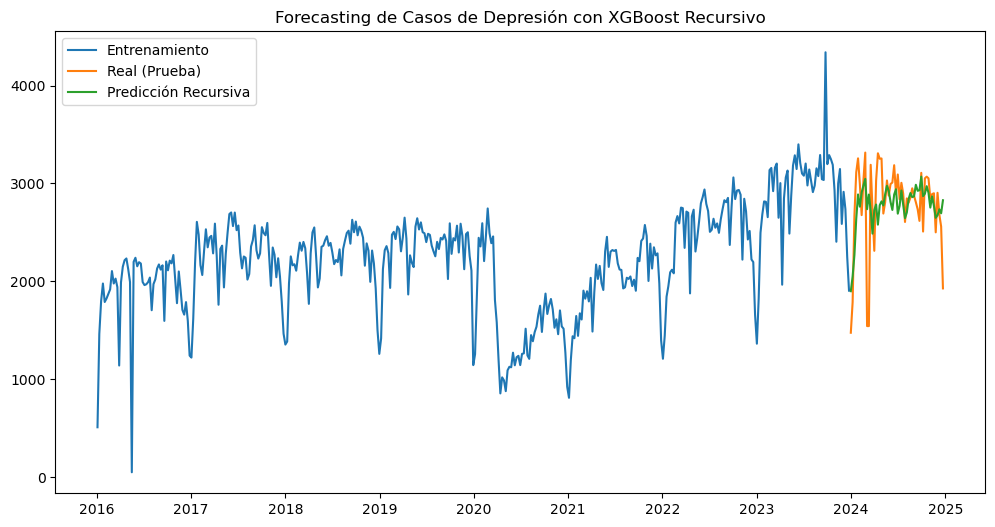

In [54]:
# --- Visualización (Opcional) ---
plt.figure(figsize=(12, 6))
plt.plot(y_train, label='Entrenamiento')
plt.plot(forecast_df_4['Actual'], label='Real (Prueba)')
plt.plot(forecast_df_4['XGBoost_Recursive'], label='Predicción Recursiva')
plt.title('Forecasting de Casos de Depresión con XGBoost Recursivo')
plt.legend()
plt.show()

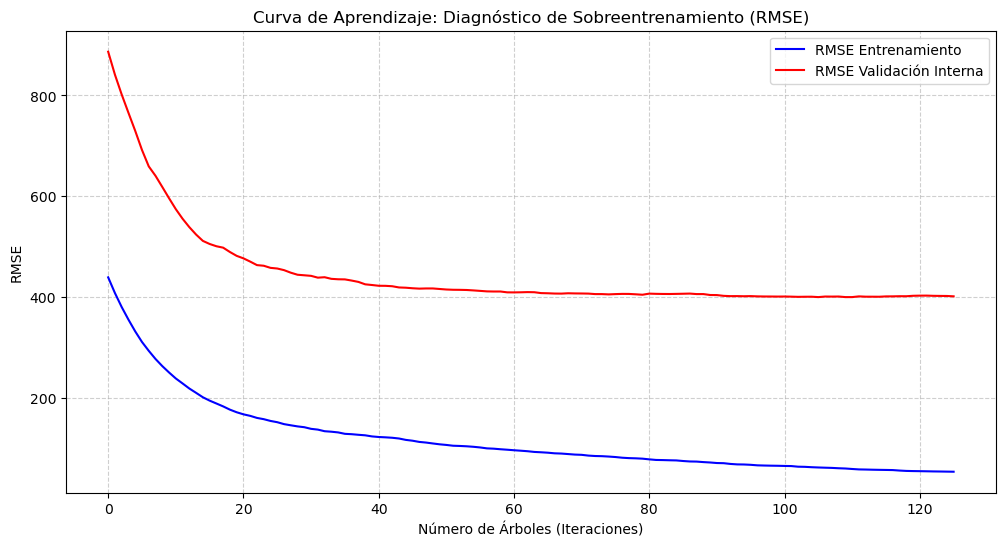

In [55]:
# --- 3. Extraer Resultados ---
results = model_history.evals_result()
epochs = len(results['validation_0']['rmse'])

# --- 4. Crear el Gráfico de la Curva de Aprendizaje ---
plt.figure(figsize=(12, 6))

# Curva de Entrenamiento (validation_0)
plt.plot(
    results['validation_0']['rmse'], 
    label='RMSE Entrenamiento', 
    color='blue'
)

# Curva de Validación (validation_1)
plt.plot(
    results['validation_1']['rmse'], 
    label='RMSE Validación Interna', 
    color='red'
)

plt.title('Curva de Aprendizaje: Diagnóstico de Sobreentrenamiento (RMSE)')
plt.xlabel('Número de Árboles (Iteraciones)')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### XGBoost con Df logarítmico

In [56]:
# --- CONFIGURACIÓN GLOBAL
FORECAST_HORIZON = 52  # Semanas de prueba
BREAK_DATE = pd.to_datetime('2020-04-01')

def create_advanced_features_log(data, lag_steps=52, n_fourier=6):
    """
    Crea features avanzadas, transformando la variable objetivo 'y' y sus lags a escala logarítmica (ln).
    """
    df_features = data.copy()
    
    # 1. CLAVE: Transformar la variable objetivo a escala logarítmica
    # Creamos una nueva columna logarítmica para el entrenamiento
    df_features['y_log'] = np.log(df_features['y'])
    
    # --- A. Features Temporales (Tendencia, Fourier) ---
    df_features['time_index'] = np.arange(len(df_features))
    scaler_time = StandardScaler()
    df_features['Trend_Global'] = scaler_time.fit_transform(df_features[['time_index']])
    df_features.drop(columns=['time_index'], inplace=True) 

    P = 52.17 
    t = np.arange(len(df_features))
    for k in range(1, n_fourier + 1):
        df_features[f'sin_{k}'] = np.sin(2 * np.pi * k * t / P)
        df_features[f'cos_{k}'] = np.cos(2 * np.pi * k * t / P)

    # --- B. Quiebre Estructural ---
    df_features['Is_Post_Quiebre'] = (df_features.index >= BREAK_DATE).astype(int)
    df_features['Trend_Post_Quiebre'] = 0
    post_quiebre_indices = df_features[df_features['Is_Post_Quiebre'] == 1].index
    if not post_quiebre_indices.empty:
        post_quiebre_counter = np.arange(1, len(post_quiebre_indices) + 1)
        df_features.loc[post_quiebre_indices, 'Trend_Post_Quiebre'] = post_quiebre_counter
        scaler_post = StandardScaler()
        df_features.loc[post_quiebre_indices, 'Trend_Post_Quiebre'] = \
            scaler_post.fit_transform(df_features.loc[post_quiebre_indices, ['Trend_Post_Quiebre']])

    # --- C. Lags (CLAVE: basados en 'y_log') ---
    for i in range(1, lag_steps + 1):
        # Los lags ahora son los valores logarítmicos pasados
        df_features[f'lag_{i}'] = df_features['y_log'].shift(i)
        
    df_features['prediction_step'] = 0

    # Retornamos solo las columnas necesarias, 'y_log' es nuestro nuevo target
    return df_features.drop(columns=['y']).dropna()

In [57]:
# --- FUNCIÓN DE FORECASTING RECURSIVO CON INVERSIÓN ---
def recursive_forecast_log(model, initial_X_test, horizon, lag_steps=52):
    """
    Realiza predicciones recursivas, propagando la predicción logarítmica y 
    convirtiendo el resultado final a la escala original (exponencial).
    """
    current_X = initial_X_test.copy()
    predictions_log = []

    for step in range(horizon):
        # 1. Predecir en la escala logarítmica
        X_now = current_X.iloc[[step]].copy()
        pred_value_log = model.predict(X_now)[0]
        predictions_log.append(pred_value_log)

        # 2. Propagar el lag logarítmico para el siguiente paso (si no es el último)
        if step < horizon - 1:
            # Desplazar todos los lags y usar la nueva predicción como lag_1
            # (Asumimos que la lógica de desplazamiento de lags está correctamente implementada aquí)
            current_X.iloc[step + 1, current_X.columns.get_loc('lag_1')] = pred_value_log

    # 3. CLAVE: Aplicar la transformación inversa (exponencial) a las predicciones finales
    final_predictions_original_scale = np.exp(np.array(predictions_log))
    
    return final_predictions_original_scale

In [58]:
def rmse_original_scale_scorer(model, X, y_log):
    """
    Calcula el RMSE en la escala original para la evaluación de CV.
    y_log: es la variable objetivo en la escala logarítmica (debe ser un numpy array o Series).
    """
    # 1. Predecir en escala logarítmica
    y_pred_log = model.predict(X)
    
    # 2. Invertir la transformación a escala original
    y_true_original = np.exp(y_log)
    y_pred_original = np.exp(y_pred_log)
    
    # 3. Calcular RMSE en la escala original
    return np.sqrt(mean_squared_error(y_true_original, y_pred_original))

In [59]:
df_features_log = create_advanced_features_log(df_features_ext.copy(), lag_steps=52, n_fourier=6)

In [63]:
# Definición del horizonte de predicción (por ejemplo, las últimas 52 semanas/1 año)
FORECAST_HORIZON = 52

# Definición de X (features) e y (target)
target = 'y_log'
features = [col for col in df_features_log.columns if col not in [target, 'ds', 'y_log']]

In [64]:
# 1.1 División Principal (Entrenamiento Total vs. Prueba Final)
train_cutoff = df_features_log.index[-FORECAST_HORIZON]
X_train_full = df_features_log.loc[df_features_log.index < train_cutoff, features]
y_train_full = df_features_log.loc[df_features_log.index < train_cutoff, target]

X_test_initial = df_features_log.loc[df_features_log.index >= train_cutoff, features]
y_test_log = df_features_log.loc[df_features_log.index >= train_cutoff, target] # y_test en escala LOG
y_test_original = np.exp(y_test_log) # Y REAL para la evaluación final

In [65]:
# 1.2 División para la Curva de Aprendizaje (Training vs. Validation Interna)
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, shuffle=False, random_state=42
)

# 1.3 Datos para Búsqueda
X = X_train_full
y = y_train_full

In [76]:
# --- 2. BÚSQUEDA DE HIPERPARÁMETROS (USANDO RMSE LOG PARA EFICIENCIA) ---

tscv = TimeSeriesSplit(n_splits=5, test_size=52)
rmse_scorer_log = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)

param_grid_final = {
    'n_estimators': [100, 200, 300, 500, 750], 'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4], 'min_child_weight': [10, 20, 30], 
    'reg_alpha': [0.1, 0.5, 1, 2, 5], 'reg_lambda': [0.1, 0.5, 1, 2, 5],  
    'colsample_bytree': [0.7, 0.9, 1.0]
}

xgb = XGBRegressor(random_state=42, tree_method='hist')
random_search = RandomizedSearchCV(
    estimator=xgb, 
    param_distributions=param_grid_final, 
    n_iter=50, 
    scoring=rmse_scorer_log,
      cv=tscv, 
      n_jobs=-1, 
      random_state=42
)

print("Iniciando la búsqueda de hiperparámetros con regularización estricta...")
random_search.fit(X, y)
best_rmse_cv_log = -random_search.best_score_
best_params = random_search.best_params_.copy()

Iniciando la búsqueda de hiperparámetros con regularización estricta...

--- Resultados de la Búsqueda Final ---
Mejor RMSE (Log Scale) promedio en CV: -0.1957
🏆 RMSE APROXIMADO DE CV (Escala Original): -187.86
Mejores Hiperparámetros: {'reg_lambda': 0.1, 'reg_alpha': 2, 'n_estimators': 100, 'min_child_weight': 30, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [77]:
# --- RE-EVALUAR EL MEJOR MODELO EN ESCALA ORIGINAL ---
best_model_cv = random_search.best_estimator_
# Re-evaluar el mejor modelo en el set de validación usando la métrica de escala original
rmse_original_scorer = make_scorer(rmse_original_scale_scorer, greater_is_better=False)
best_rmse_cv_original = rmse_original_scale_scorer(best_model_cv, X_train_full, y_train_full) * -1 # Multiplicar por -1 ya que el scorer es "mayor es mejor"

print(f"\n--- Resultados de la Búsqueda Final ---")
print(f"Mejor RMSE (Log Scale) promedio en CV: {best_rmse_cv_log:.4f}")
print(f"🏆 RMSE APROXIMADO DE CV (Escala Original): {-best_rmse_cv_original:.2f}")
print(f"Mejores Hiperparámetros: {best_params}")


--- Resultados de la Búsqueda Final ---
Mejor RMSE (Log Scale) promedio en CV: 0.1957
🏆 RMSE APROXIMADO DE CV (Escala Original): 187.86
Mejores Hiperparámetros: {'reg_lambda': 0.1, 'reg_alpha': 2, 'n_estimators': 100, 'min_child_weight': 30, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [88]:
# --- 3. ENTRENAMIENTO PARA LA CURVA Y PARADA TEMPRANA ---
if 'n_estimators' in best_params: del best_params['n_estimators']

final_model = XGBRegressor(
    random_state=42, 
    tree_method='hist', 
    n_estimators=3000, 
    eval_metric="rmse", 
    early_stopping_rounds=50, 
    **best_params
)

# Creamos y_val original para la métrica de la curva
y_val_original = np.exp(y_val)
y_train_original_curve = np.exp(y_train_model)

eval_set_final = [(X_train_model, y_train_model), (X_val, y_val)]

print("\nIniciando entrenamiento final con Early Stopping para generar la curva...")
model_history = final_model.fit(
    X_train_model, y_train_model, eval_set=eval_set_final, verbose=False
)

optimal_n_estimators = final_model.best_iteration
print(f"✅ Entrenamiento Finalizado por Parada Temprana en {optimal_n_estimators} árboles.")


Iniciando entrenamiento final con Early Stopping para generar la curva...
✅ Entrenamiento Finalizado por Parada Temprana en 206 árboles.


In [68]:
# --- 4. FORECASTING RECURSIVO Y EVALUACIÓN FINAL ---

# Re-entrenamos con el número óptimo de árboles en todo el X_train completo (si es necesario)
# Ya que XGBoost es aditivo, solo necesitamos ajustar n_estimators al valor óptimo:
final_model.set_params(n_estimators=optimal_n_estimators)

# Ejecutar el Forecasting Recursivo con el modelo ya entrenado
final_predictions = recursive_forecast_log(final_model, X_test_initial.copy(), FORECAST_HORIZON)

# Crear un DataFrame para los resultados
forecast_df_5 = pd.DataFrame({
    'Actual': y_test_original.values,
    'XGBoost_Recursive': final_predictions
}, index=y_test_original.index)

In [89]:
# --- Evaluación Final ---
mse_final = mean_squared_error(y_test_original, final_predictions)
rmse_final = np.sqrt(mse_final)

print(f"\n--- Rendimiento del Modelo Final ---")
print(f"Error Cuadrático Medio (RMSE) en el set de prueba recursivo final: {rmse_final:.2f}")


--- Rendimiento del Modelo Final ---
Error Cuadrático Medio (RMSE) en el set de prueba recursivo final: 462.26


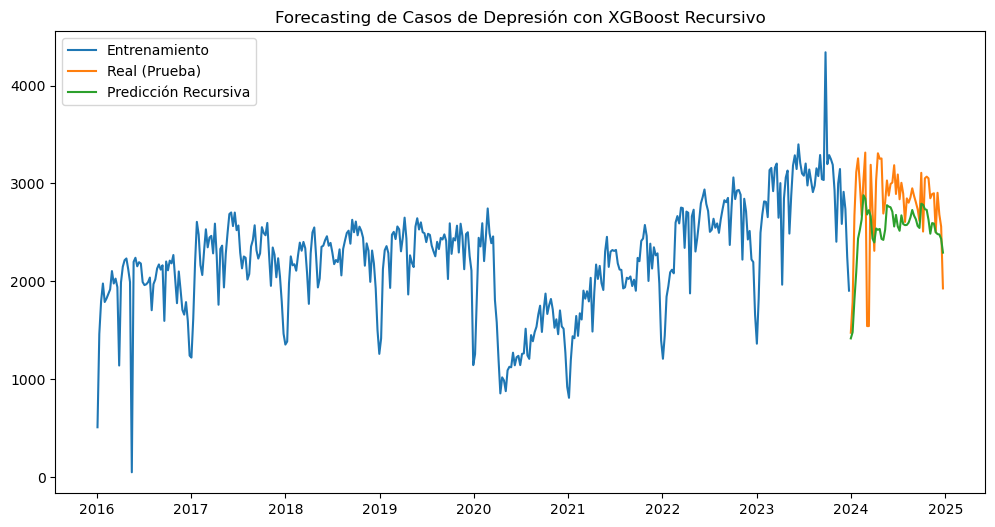

In [90]:
# --- Visualización (Opcional) ---
plt.figure(figsize=(12, 6))
plt.plot(np.exp(y_train_full), label='Entrenamiento')
plt.plot(forecast_df_5['Actual'], label='Real (Prueba)')
plt.plot(forecast_df_5['XGBoost_Recursive'], label='Predicción Recursiva')
plt.title('Forecasting de Casos de Depresión con XGBoost Recursivo')
plt.legend()
plt.show()

### Random Forest

In [101]:
# Definición del horizonte de predicción (por ejemplo, las últimas 52 semanas/1 año)
FORECAST_HORIZON = 52

# Definición de X (features) e y (target)
target = 'y'
features = [col for col in df_features_ext_v2.columns if col not in [target, 'ds']]

In [102]:
# Separar conjuntos de Entrenamiento y Prueba
# Entrenamiento: todos los datos menos el horizonte de predicción
train_cutoff = df_features_ext_v2.index[-FORECAST_HORIZON]
X_train = df_features_ext_v2.loc[df_features_ext_v2.index < train_cutoff, features]
y_train = df_features_ext_v2.loc[df_features_ext_v2.index < train_cutoff, target]

# Prueba: solo el horizonte de predicción
X_test_initial = df_features_ext_v2.loc[df_features_ext_v2.index >= train_cutoff, features]
y_test = df_features_ext_v2.loc[df_features_ext_v2.index >= train_cutoff, target]

In [103]:
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.1, 
    shuffle=False, # ¡Importante! No mezclar datos de series de tiempo.
    random_state=42
)

In [104]:
df_train = df_features_ext_v2.dropna()
X = df_train.drop(columns=['y', 'prediction_step']) # Excluimos el target y el indicador recursivo
y = df_train['y']

In [105]:
from sklearn.ensemble import RandomForestRegressor
# from xgboost import XGBRegressor # Ya no se usa

# --- 1. PREPARACIÓN DE DATOS (Mismos datos) ---
# Asumiendo que df_features_ext_v2, X, y, tscv, X_train_model, y_train_model, X_val, y_val, etc.
# ya están definidos como en tu código original.

# --- 2. BÚSQUEDA DE HIPERPARÁMETROS CON RANDOM FOREST ---
# Definición de CV y Scorer (Se mantienen)
tscv = TimeSeriesSplit(n_splits=5, test_size=52)
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)

# Espacio de Búsqueda para Random Forest
param_grid_rf = {
    # Número de árboles (se probará un rango)
    'n_estimators': [100, 200, 300, 500, 750, 1000], 
    
    # **CLAVE:** Reducir la profundidad máxima del árbol para controlar el sobreajuste
    'max_depth': [None, 10, 15, 20], 
    
    # Número mínimo de muestras requeridas para dividir un nodo
    'min_samples_split': [2, 5, 10], 
    
    # Número mínimo de muestras requeridas en un nodo hoja
    'min_samples_leaf': [1, 5, 10, 20], 
    
    # Número de características a considerar al buscar la mejor división
    'max_features': [1.0, 'sqrt', 'log2'], # 1.0 es lo mismo que max_features = n_features
}

In [106]:
# Inicializar el modelo de Random Forest
rf = RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=True) # n_jobs=-1 para paralelizar

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid_rf,
    n_iter=50, # Número de combinaciones a probar
    scoring=rmse_scorer,
    cv=tscv,
    verbose=0,
    n_jobs=-1,
    random_state=42
)

print("Iniciando la búsqueda de hiperparámetros con Random Forest...")

# En Random Forest, se usa todo el set de entrenamiento 'X' para la búsqueda CV
random_search_rf.fit(X_train, y_train) 
best_rmse_cv = -random_search_rf.best_score_
best_params = random_search_rf.best_params_

print("\n--- Resultados de la Búsqueda v2 (Random Forest) ---")
print(f"Mejor RMSE promedio en validación (CV): {best_rmse_cv:.2f}")
print(f"Mejores Hiperparámetros: {best_params}")

Iniciando la búsqueda de hiperparámetros con Random Forest...

--- Resultados de la Búsqueda v2 (Random Forest) ---
Mejor RMSE promedio en validación (CV): 383.65
Mejores Hiperparámetros: {'n_estimators': 750, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 20}


In [107]:
# --- 3. ENTRENAMIENTO FINAL (Random Forest) ---
# El Random Forest no requiere early stopping. Se entrena con todos los datos de entrenamiento
# y el número óptimo de estimadores de la búsqueda, o un número razonablemente alto.

# Inicializar y entrenar el modelo final con los parámetros óptimos en el conjunto X_train completo
final_model_rf = RandomForestRegressor(
    random_state=42, 
    n_jobs=-1, 
    oob_score=True, # Calculamos el error OOB (opcional)
    **best_params
)

# Entrenar el modelo final usando el conjunto de entrenamiento principal (X_train y y_train)
print("\nIniciando entrenamiento final de Random Forest...")
final_model_rf.fit(X_train, y_train)

# El concepto de optimal_n_estimators no aplica, ya que todos los árboles se entrenan a la vez.
print(f"✅ Entrenamiento Finalizado. Número de árboles: {final_model_rf.n_estimators}.")
# print(f"Error OOB: {1 - final_model_rf.oob_score_:.4f}") # Opcional: Error Out-of-Bag


Iniciando entrenamiento final de Random Forest...
✅ Entrenamiento Finalizado. Número de árboles: 750.


In [ ]:
# --- 5. FORECASTING RECURSIVO Y EVALUACIÓN FINAL ---

# Reutiliza la función 'recursive_forecast'
final_predictions_rf = recursive_forecast(final_model_rf, X_test_initial.copy(), FORECAST_HORIZON)

# Crear un DataFrame para los resultados
forecast_df_rf = pd.DataFrame({
    'Actual': y_test.values,
    'RandomForest_Recursive': final_predictions_rf
}, index=y_test.index)

In [109]:
# --- Evaluación Final ---
mse_final_rf = mean_squared_error(y_test, final_predictions_rf)
rmse_final_rf = np.sqrt(mse_final_rf)

print(f"\n--- Rendimiento del Modelo Final (Random Forest) ---")
print(f"Error Cuadrático Medio (RMSE) en el set de prueba recursivo final: {rmse_final_rf:.2f}")


--- Rendimiento del Modelo Final (Random Forest) ---
Error Cuadrático Medio (RMSE) en el set de prueba recursivo final: 511.78


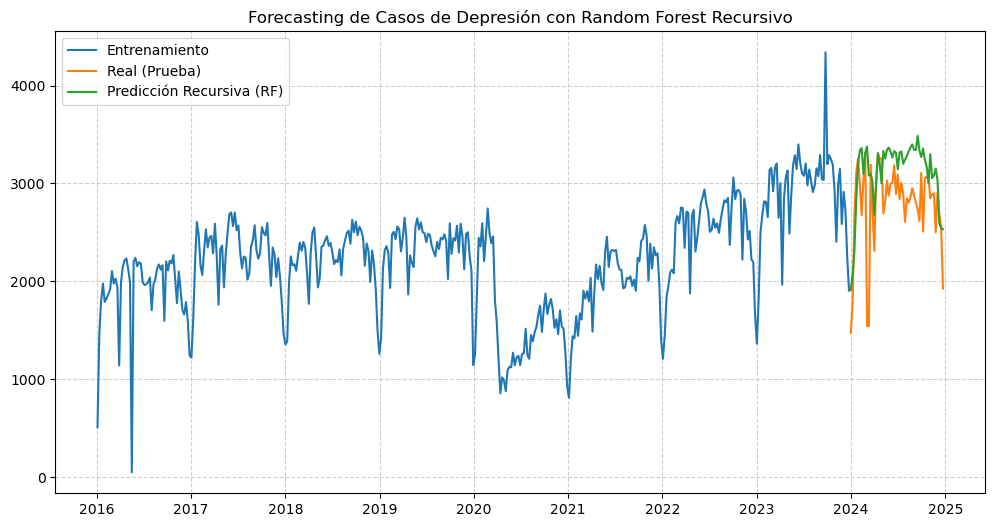

In [110]:
# --- Visualización ---
plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train.values, label='Entrenamiento')
plt.plot(forecast_df_rf['Actual'], label='Real (Prueba)')
plt.plot(forecast_df_rf['RandomForest_Recursive'], label='Predicción Recursiva (RF)')
plt.title('Forecasting de Casos de Depresión con Random Forest Recursivo')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()